# Introduction

In this notebook, I create a simple convolutional neural network for classification.

## Installing libraries

In [1]:
!pip3 install torch torchvision Pillow

## CUDA and PyTorch check

In [2]:
!nvcc --version
import torch
haveCuda = torch.cuda.is_available()
print(haveCuda)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
True


## Download and unzip databse

In [3]:
!wget http://deeplearning.iit.bme.hu/Public/DL/RoboCupClass.zip --no-check-certificate

!unzip -qq RoboCupClass.zip

--2025-11-08 08:59:19--  http://deeplearning.iit.bme.hu/Public/DL/RoboCupClass.zip
Resolving deeplearning.iit.bme.hu (deeplearning.iit.bme.hu)... 152.66.243.112
Connecting to deeplearning.iit.bme.hu (deeplearning.iit.bme.hu)|152.66.243.112|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://deeplearning.iit.bme.hu/Public/DL/RoboCupClass.zip [following]
--2025-11-08 08:59:21--  https://deeplearning.iit.bme.hu/Public/DL/RoboCupClass.zip
Connecting to deeplearning.iit.bme.hu (deeplearning.iit.bme.hu)|152.66.243.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31111398 (30M) [application/zip]
Saving to: ‘RoboCupClass.zip’

RoboCupClass.zip    100%[===================>]  29.67M  12.3MB/s    in 2.4s    

2025-11-08 08:59:24 (12.3 MB/s) - ‘RoboCupClass.zip’ saved [31111398/31111398]



# Solution

## Progress bar

In [4]:
from IPython.display import HTML, display

def progress(value, max=100):
    return HTML("""
        <progress
            value='{value}'
            max='{max}',
            style='width: 100%'
        >
            {value}
        </progress>
    """.format(value=value, max=max))

## Creating conv. network

In [5]:
import torch
import torch.nn as nn

class Conv(nn.Module):
  def __init__(self, inch, ch, size, stride=1):
    super().__init__()
    self.conv = nn.Conv2d(inch, ch, size, stride, padding=size//2)
    self.bn = nn.BatchNorm2d(ch)

  def forward(self, x):
    return self.bn(torch.relu(self.conv(x)))

class ConvNet(nn.Module):
  def __init__(self, base_ch, nClass=5, size=3):
    super().__init__()

    self.c11 = Conv(3, base_ch, size)
    self.c12 = Conv(base_ch, base_ch, size)
    self.d1 =  Conv(base_ch, base_ch*2, size, stride=2) #downscale

    self.c21 = Conv(base_ch*2, base_ch*2, size)
    self.c22 = Conv(base_ch*2, base_ch*2, size)
    self.d2 =  Conv(base_ch*2, base_ch*4, size, stride=2)

    self.c31 = Conv(base_ch*4, base_ch*4, size)
    self.c32 = Conv(base_ch*4, base_ch*4, size)
    self.d3 =  Conv(base_ch*4, base_ch*8, size, stride=2)

    self.c41 = Conv(base_ch*8, base_ch*8, size)
    self.c42 = Conv(base_ch*8, base_ch*8, size)
    self.d4 =  Conv(base_ch*8, base_ch*16, size, stride=2)

    self.c51 = Conv(base_ch*16, base_ch*16, size)
    self.c52 = Conv(base_ch*16, base_ch*16, size)
    self.d5 =  Conv(base_ch*16, base_ch*32, size, stride=2)

    self.classifier = nn.Conv2d(base_ch*32, nClass, 1) #lényegében egy lineáris réteg

  def forward(self, x):
    x = self.d1(self.c12(self.c11(x)))
    x = self.d2(self.c22(self.c21(x)))
    x = self.d3(self.c32(self.c31(x)))
    x = self.d4(self.c42(self.c41(x)))
    x = self.d5(self.c52(self.c51(x)))
    return torch.squeeze(self.classifier(x))




## Preparing data

### Data augmentations

In [6]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.25, 0.25, 0.2, 0.15),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.5, 0.5, 0.5],
            [0.25, 0.25, 0.25]
    )
    ]
)

transform_val = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            [0.5, 0.5, 0.5],
            [0.25, 0.25, 0.25]
        )
    ]
)

### Database

In [7]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

trainSet = ImageFolder("Classification/train/", transform)
valSet = ImageFolder("Classification/val/", transform_val)

### Dataloader

In [8]:
trainLoader = DataLoader(trainSet, batch_size=128, shuffle = True)
valLoader = DataLoader(valSet, batch_size=128, shuffle = True)


## Epoch functions

### Train

In [9]:
def train(epoch):

  running_loss = 0
  correct = 0
  total = 0

  net.train()

  # Create progress bar
  bar = display(progress(0, len(trainLoader)), display_id=True)

  for i, data in enumerate(trainLoader):
    inputs, labels = data

    if haveCuda:
      inputs, labels = inputs.cuda(), labels.cuda()

    optimizer.zero_grad()
    outputs = net(inputs)

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    total += labels.shape[0]
    _, predicted = torch.max(outputs, 1)
    correct += (predicted == labels).sum().item()

    bar.update(progress(i+1, len(trainLoader)))

  total_loss = running_loss / len(trainLoader)
  accuracy = correct/total*100
  print("Train epoch %d loss: %.3f accuracy: %.2f" % (epoch, total_loss, accuracy))

  return total_loss, accuracy

### Validate

In [10]:
def val(epoch):

  running_loss = 0
  correct = 0
  total = 0

  net.eval()

  # Create progress bar
  bar = display(progress(0, len(valLoader)), display_id=True)

  for i, data in enumerate(valLoader):
    inputs, labels = data

    if haveCuda:
      inputs, labels = inputs.cuda(), labels.cuda()

    outputs = net(inputs)
    loss = criterion(outputs, labels)

    running_loss += loss.item()
    total += labels.shape[0]
    _, predicted = torch.max(outputs, 1)
    correct += (predicted == labels).sum().item()

    bar.update(progress(i+1, len(valLoader)))

  total_loss = running_loss / len(valLoader)
  accuracy = correct/total*100
  print("Val epoch %d loss: %.3f accuracy: %.2f" % (epoch, total_loss, accuracy))

  return total_loss, accuracy

## Main training function

Train epoch 0 loss: 1.387 accuracy: 53.19


Val epoch 0 loss: 0.875 accuracy: 68.24
Best model


Train epoch 1 loss: 0.706 accuracy: 73.71


Val epoch 1 loss: 0.592 accuracy: 80.03
Best model


Train epoch 2 loss: 0.525 accuracy: 79.67


...

Val epoch 17 loss: 0.102 accuracy: 96.38


Train epoch 18 loss: 0.142 accuracy: 95.14


Val epoch 18 loss: 0.102 accuracy: 96.41


Train epoch 19 loss: 0.144 accuracy: 95.10


Val epoch 19 loss: 0.104 accuracy: 96.32


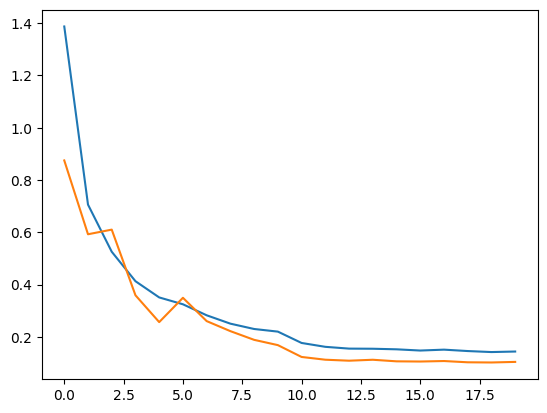

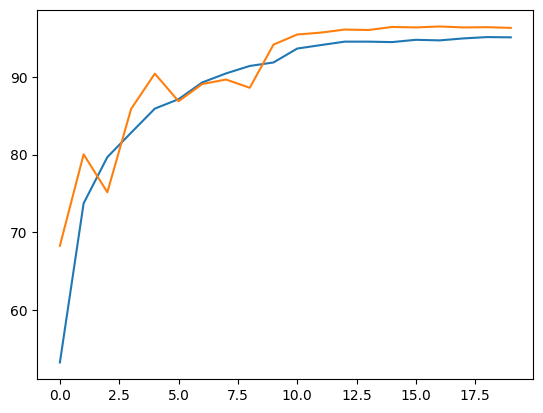

In [11]:
import torch.optim as optim
from torch.optim import lr_scheduler

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

torch.manual_seed(42)
if haveCuda:
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

net = ConvNet(8)
if haveCuda:
  net=net.cuda()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9, nesterov=True, weight_decay=1e-4)

scheduler = lr_scheduler.StepLR(optimizer, 10)

numEpoch = 20

trLosses = []
trAccs = []
valLosses = []
valAccs = []

best_acc = 0

for epoch in range(numEpoch):
  tr_loss, tr_acc = train(epoch)
  v_loss, v_acc = val(epoch)

  trLosses.append(tr_loss)
  trAccs.append(tr_acc)
  valLosses.append(v_loss)
  valAccs.append(v_acc)

  scheduler.step()

  if v_acc > best_acc:
    print("Best model")
    best_acc = v_acc
    torch.save(net, "best.pt")

plt.plot(trLosses)
plt.plot(valLosses)
plt.show()
plt.plot(trAccs)
plt.plot(valAccs)
plt.show()


## Vizualization

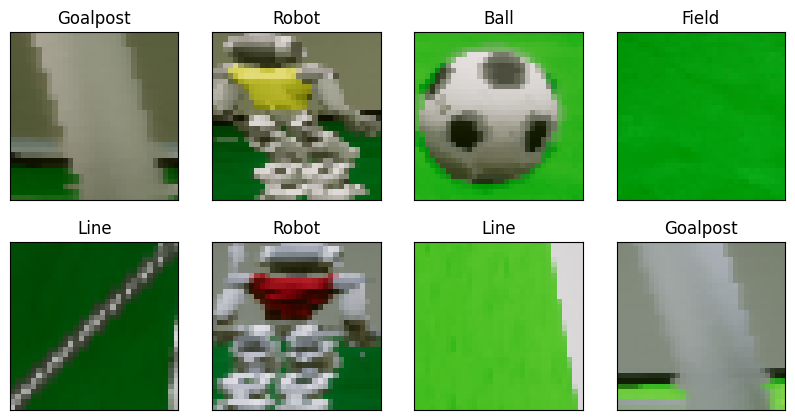

In [12]:
inputs, labels = next(iter(valLoader))
if haveCuda:
    inputs, labels = inputs.cuda(), labels.cuda()

# forward
outputs = net(inputs)

_, predicted = torch.max(outputs, 1)

mean = torch.Tensor((0.49139968, 0.48215827, 0.44653124)).unsqueeze(1).unsqueeze(1)
std = torch.Tensor((0.24703233, 0.24348505, 0.26158768)).unsqueeze(1).unsqueeze(1)

f, axarr = plt.subplots(2, 4,figsize=(10, 5))

for i,(img,pred) in enumerate(zip(inputs,predicted)):
    img_rescaled = img.cpu() * std + mean
    pr = pred.cpu().item()
    name = "Field" if pr == 0 else ("Ball" if pr == 1 else ("Robot" if pr == 2 else ("Goalpost" if pr == 3 else "Line")))

    axarr[i//4,i%4].imshow(img_rescaled.permute(1,2,0))
    axarr[i//4,i%4].set_title(name)
    # Hide grid lines
    axarr[i//4,i%4].grid(False)
    # Hide axes ticks
    axarr[i//4,i%4].set_xticks([])
    axarr[i//4,i%4].set_yticks([])
    if i == 7:
        break